In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import os

In [3]:
def softplus(x):
    return torch.log(1 + torch.exp(x))

# contrainst for convex and increasing functions
def positive_weights(W):
    return F.softplus(W)

### Generating Dataset

In [4]:
# Equation 1: f = exp(-0.5x) + log(1+exp(0.4y)) + tanh(t) + sin(z) - 0.4
def toy_function1(x, y, t, z):
    return(
        torch.exp(-0.5 * x) + torch.log(1 + torch.exp(0.4 * y))
        + torch.tanh(t) + torch.sin(z) - 0.4
    ) #both equations were given in paper

def toy_function2(x, y, t, z):
    fx = torch.exp(-0.3 * x)
    fy = (0.15 * y)**2
    ft = torch.tanh(0.3 * t)
    fz = 0.2 * torch.sin(0.5*z+2) + 0.5

    return fx*fy*ft*fz

using scipy's qmc function for Latin Hypercube Sampling implementation.

In [5]:
from scipy.stats import qmc 

def generate_dataset(n_samples, low, high, func):
    # Initialize LHS sampler for 4 dimensions(x,y,t,z)
    sampler = qmc.LatinHypercube(d=4)
    sample = sampler.random(n=n_samples)
    
    scaled_samples = qmc.scale(sample, low, high)
    
    # Converting to tensors
    x = torch.tensor(scaled_samples[:, 0:1], dtype=torch.float32)
    y = torch.tensor(scaled_samples[:, 1:2], dtype=torch.float32)
    t = torch.tensor(scaled_samples[:, 2:3], dtype=torch.float32)
    z = torch.tensor(scaled_samples[:, 3:4], dtype=torch.float32)
    
    f = func(x, y, t, z)
    return x, y, t, z, f

### ISNN1

In [6]:
class ISNN1(nn.Module):
    def __init__(self, hidden=10, Hy=2, Hz=2, Ht=2, Hx=2):
        super().__init__()

        self.hidden = hidden

        # y branch(convex + monotonic -> positive weights)
        self.y_layers = nn.ModuleList(
            [nn.Linear(1 if i==0 else hidden, hidden) for i in range(Hy)]
        )

        # z branch(free)
        self.z_layers = nn.ModuleList(
            [nn.Linear(1 if i==0 else hidden, hidden) for i in range(Hz)]
        )

        # t branch (monotonic -> positive weights)
        self.t_layers = nn.ModuleList(
            [nn.Linear(1 if i==0 else hidden, hidden) for i in range(Ht)]
        )

        # x branch
        # fusion layer(x1)
        self.wf_x0 = nn.Linear(1, hidden)
        self.wf_y  = nn.Linear(hidden, hidden)
        self.wf_z  = nn.Linear(hidden, hidden)  
        self.wf_t  = nn.Linear(hidden, hidden)

        # remaining x layers(Hx-1)
        self.x_layers = nn.ModuleList(
            [nn.Linear(hidden, hidden) for _ in range(Hx-1)]
        )

        # output
        self.out = nn.Linear(hidden, 1)

    def forward(self, x0, y0, z0, t0):

        y, z, t = y0, z0, t0

        for layer in self.y_layers:
            y = F.softplus(F.linear(y, torch.abs(layer.weight), layer.bias))  # enforce ≥0 weights

        for layer in self.z_layers:
            z = torch.sigmoid(layer(z))  # free

        for layer in self.t_layers:
            t = torch.sigmoid(F.linear(t, torch.abs(layer.weight), layer.bias))  # ≥0 weights

        # only y and t must have positive weights
        x = F.softplus(
            self.wf_x0(x0) + 
            F.linear(y, torch.abs(self.wf_y.weight), self.wf_y.bias) +
            self.wf_z(z) +
            F.linear(t, torch.abs(self.wf_t.weight), self.wf_t.bias)
        )

        for layer in self.x_layers:
            x = F.softplus(F.linear(x, torch.abs(layer.weight), layer.bias))

        return self.out(x)

### ISNN2

In [7]:
class ISNN2(nn.Module):
    def __init__(self, hidden=15, H=3):
        super().__init__()

        self.H = H
        h = hidden

        # H-1 layers for each branch
        self.y_branch = nn.ModuleList(
            [nn.Linear(1 if i==0 else h, h) for i in range(H-1)]
        )
        self.z_branch = nn.ModuleList(
            [nn.Linear(1 if i==0 else h, h) for i in range(H-1)]
        )
        self.t_branch = nn.ModuleList(
            [nn.Linear(1 if i==0 else h, h) for i in range(H-1)]
        )

        # x layer 0 
        self.Wx0 = nn.Linear(1, h, bias=False)   # free
        self.Wy0 = nn.Linear(1, h, bias=False)   # ≥0
        self.Wz0 = nn.Linear(1, h, bias=False)   # free
        self.Wt0 = nn.Linear(1, h, bias=False)   # ≥0
        self.b0  = nn.Parameter(torch.zeros(h))

        # x layers
        self.Wxx  = nn.ModuleList()
        self.Wx0s = nn.ModuleList()
        self.Wxy  = nn.ModuleList()
        self.Wxz  = nn.ModuleList()
        self.Wxt  = nn.ModuleList()
        self.bias = nn.ParameterList()

        for i in range(H-1):
            out_dim = 1 if i == H-2 else h

            self.Wxx.append(nn.Linear(h, out_dim, bias=False))   # ≥0
            self.Wx0s.append(nn.Linear(1, out_dim, bias=False))  # free
            self.Wxy.append(nn.Linear(h, out_dim, bias=False))   # ≥0
            self.Wxz.append(nn.Linear(h, out_dim, bias=False))   # free
            self.Wxt.append(nn.Linear(h, out_dim, bias=False))   # ≥0

            self.bias.append(nn.Parameter(torch.zeros(out_dim)))


    def forward(self, x0, y0, z0, t0):

        # compute branch states
        y_states = [y0]
        z_states = [z0]
        t_states = [t0]

        for i in range(self.H - 1):
            y_states.append(F.softplus(F.linear(y_states[-1], torch.abs(self.y_branch[i].weight), self.y_branch[i].bias)))
            z_states.append(torch.sigmoid(self.z_branch[i](z_states[-1])))
            t_states.append(torch.sigmoid(F.linear(t_states[-1], torch.abs(self.t_branch[i].weight), self.t_branch[i].bias)))

        # x layer 0 
        # Only y and t weights must be positive here
        x = F.softplus(
            self.Wx0(x0) +
            F.linear(y0, torch.abs(self.Wy0.weight)) +
            self.Wz0(z0) +
            F.linear(t0, torch.abs(self.Wt0.weight)) +
            self.b0
        )

        # x layers
        for i in range(self.H - 1):
            #Weights for x, y, and t terms must be positive
            pre = (
                F.linear(x, torch.abs(self.Wxx[i].weight)) +
                self.Wx0s[i](x0) +
                F.linear(y_states[i+1], torch.abs(self.Wxy[i].weight)) +
                self.Wxz[i](z_states[i+1]) +
                F.linear(t_states[i+1], torch.abs(self.Wxt[i].weight))+
                self.bias[i]
            )

            #according to paper, no activation in last layer
            if i == self.H - 2:
                x = pre
            else:
                x = F.softplus(pre)

        return x

### base NN

In [8]:
class FFNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4, 30),
            nn.Softplus(),
            nn.Linear(30, 30),
            nn.Softplus(),
            nn.Linear(30, 1)
        )

    def forward(self, x, y, z, t):
        inp = torch.cat([x, y, z, t], dim=1)
        return self.net(inp)

### Training

In [9]:
def train_model(model, x_train, y_train, z_train, t_train, f_train,
                x_test, y_test, z_test, t_test, f_test,
                epochs=30000): # Paper uses 30,000 for toy problems but we are using 3000 here

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam used in paper
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(1, epochs+1):
        model.train()
        pred = model(x_train, y_train, z_train, t_train)
        loss = loss_fn(pred, f_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_pred = model(x_test, y_test, z_test, t_test)
            test_loss = loss_fn(test_pred, f_test)

        test_losses.append(test_loss.item())

        if epoch % 100 == 0 or epoch ==1:
            print(f"Epoch {epoch} | Train Loss: {loss.item():.6f} | Test Loss: {test_loss.item():.6f}")

    return train_losses, test_losses

In [10]:
# Function 1 Datasets
x1_train, y1_train, t1_train, z1_train, f1_train = generate_dataset(500, 0.0, 4.0, toy_function1) 
x1_test, y1_test, t1_test, z1_test, f1_test = generate_dataset(5000, 0.0, 6.0, toy_function1) 

# Function 2 Datasets
x2_train, y2_train, t2_train, z2_train, f2_train = generate_dataset(500, 0.0, 4.0, toy_function2) 
x2_test, y2_test, t2_test, z2_test, f2_test = generate_dataset(5000, 0.0, 6.0, toy_function2)

### plots

In [11]:
COLORS = {
    "FFNN": "red",
    "ISNN-1": "blue",
    "ISNN-2": "green"
}

In [12]:
def plot_loss_curves(results, log_every=1):

    plt.figure(figsize=(12, 4))
    titles = ["(a) Training Loss", "(b) Test Loss"]

    for idx, title in enumerate(titles):
        plt.subplot(1, 2, idx + 1)

        for name, data in results.items():

            # Enforce shape: (runs, epochs), here we only have 1 run per dataset
            losses = np.array([data[idx]])  # shape: (1, epochs)

            mean_loss = np.mean(losses, axis=0)
            std_loss  = np.std(losses, axis=0)

            epochs = (np.arange(len(mean_loss)) + 1) * log_every

            color = COLORS.get(name, None)

            plt.semilogy(epochs, mean_loss, label=name, color=color)
            plt.fill_between(
                epochs,
                mean_loss - std_loss,
                mean_loss + std_loss,
                alpha=0.2,
                color=color
            )

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.grid(True, which="both", alpha=0.3)

In [13]:
def plot_behavior(models, true_fn, train_max=4, test_max=6, eq_name="Eq."):

    v_full = np.linspace(0, test_max, 500)
    v_train_mask = v_full <= train_max
    v_test_mask  = v_full > train_max

    plt.figure(figsize=(5 * len(models), 4))

    for i, (name, model) in enumerate(models.items()):
        plt.subplot(1, len(models), i + 1)

        vt = torch.tensor(v_full.reshape(-1, 1), dtype=torch.float32)

        # True function
        true_vals_t = true_fn(vt, vt, vt, vt)
        true_vals = true_vals_t.numpy().flatten()
        plt.plot(v_full, true_vals, 'k-', label="True", linewidth=1.5)

        # Model prediction
        model.eval()
        with torch.no_grad():
            pred = model(vt, vt, vt, vt).cpu().numpy().flatten()

        color = COLORS.get(name, "blue")

        # Interpolation
        plt.plot(
            v_full[v_train_mask],
            pred[v_train_mask],
            linestyle='--',
            color=color,
            label="Interpolated"
        )

        # Extrapolation
        plt.plot(
            v_full[v_test_mask],
            pred[v_test_mask],
            linestyle=':',
            color=color,
            label="Extrapolated"
        )

        # Train boundary
        plt.axvline(train_max, linestyle=':', color='gray')

        plt.title(f"{name} ({eq_name})")
        plt.xlabel("v (x=y=t=z)")
        plt.ylabel("f(v,v,v,v)")
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Final Training

One with 30000 epochs(same as suggested in the paper)

In [14]:
# tried with bboth 300000 and 3000
N_EPOCHS = 30000
# N_EPOCHS = 3000
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)


--- Dataset 1 ---

Training FFNN...
Epoch 1 | Train Loss: 5.456198 | Test Loss: 4.858662
Epoch 100 | Train Loss: 0.379269 | Test Loss: 0.991882
Epoch 200 | Train Loss: 0.231101 | Test Loss: 0.622830
Epoch 300 | Train Loss: 0.205379 | Test Loss: 0.473634
Epoch 400 | Train Loss: 0.195628 | Test Loss: 0.405755
Epoch 500 | Train Loss: 0.186908 | Test Loss: 0.367341
Epoch 600 | Train Loss: 0.177153 | Test Loss: 0.337196
Epoch 700 | Train Loss: 0.163671 | Test Loss: 0.309510
Epoch 800 | Train Loss: 0.130257 | Test Loss: 0.279642
Epoch 900 | Train Loss: 0.079332 | Test Loss: 0.276656
Epoch 1000 | Train Loss: 0.042879 | Test Loss: 0.313179
Epoch 1100 | Train Loss: 0.026805 | Test Loss: 0.369438
Epoch 1200 | Train Loss: 0.020157 | Test Loss: 0.407756
Epoch 1300 | Train Loss: 0.015961 | Test Loss: 0.434513
Epoch 1400 | Train Loss: 0.012283 | Test Loss: 0.459924
Epoch 1500 | Train Loss: 0.008984 | Test Loss: 0.486440
Epoch 1600 | Train Loss: 0.006451 | Test Loss: 0.512748
Epoch 1700 | Train Loss

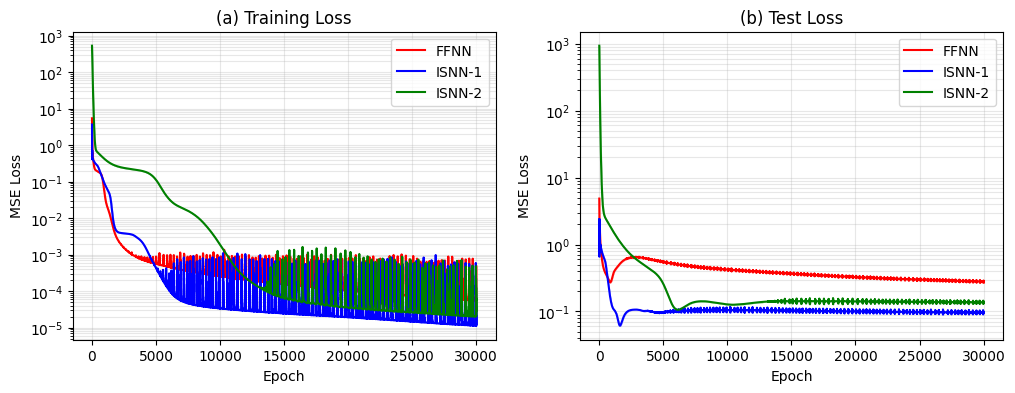

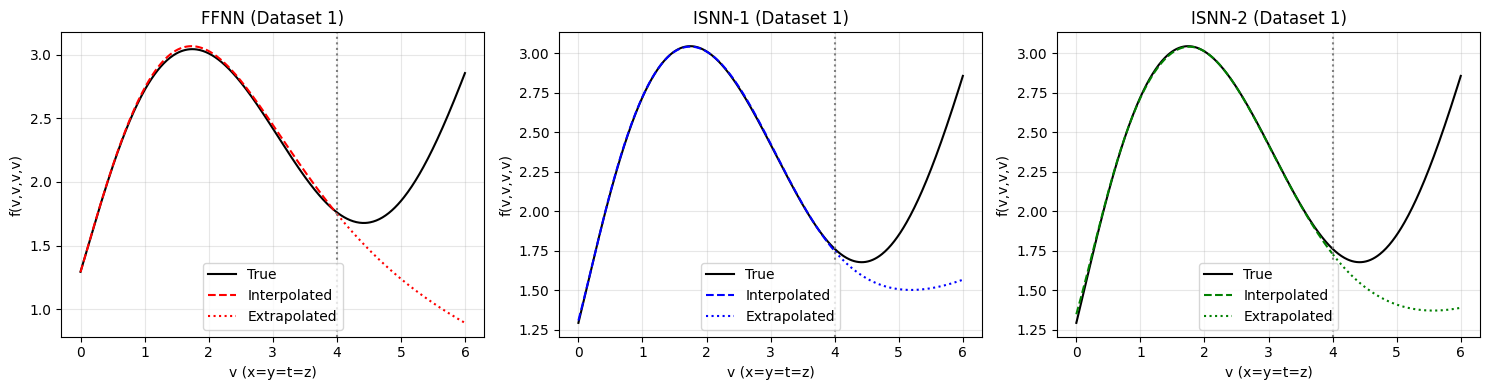


--- Dataset 2 ---

Training FFNN...
Epoch 1 | Train Loss: 0.015934 | Test Loss: 0.028784
Epoch 100 | Train Loss: 0.000226 | Test Loss: 0.001764
Epoch 200 | Train Loss: 0.000144 | Test Loss: 0.001303
Epoch 300 | Train Loss: 0.000085 | Test Loss: 0.000947
Epoch 400 | Train Loss: 0.000053 | Test Loss: 0.000724
Epoch 500 | Train Loss: 0.000039 | Test Loss: 0.000598
Epoch 600 | Train Loss: 0.000032 | Test Loss: 0.000521
Epoch 700 | Train Loss: 0.000027 | Test Loss: 0.000473
Epoch 800 | Train Loss: 0.000024 | Test Loss: 0.000440
Epoch 900 | Train Loss: 0.000022 | Test Loss: 0.000415
Epoch 1000 | Train Loss: 0.000020 | Test Loss: 0.000393
Epoch 1100 | Train Loss: 0.000019 | Test Loss: 0.000374
Epoch 1200 | Train Loss: 0.000018 | Test Loss: 0.000356
Epoch 1300 | Train Loss: 0.000017 | Test Loss: 0.000339
Epoch 1400 | Train Loss: 0.000017 | Test Loss: 0.000323
Epoch 1500 | Train Loss: 0.000016 | Test Loss: 0.000309
Epoch 1600 | Train Loss: 0.000015 | Test Loss: 0.000295
Epoch 1700 | Train Loss

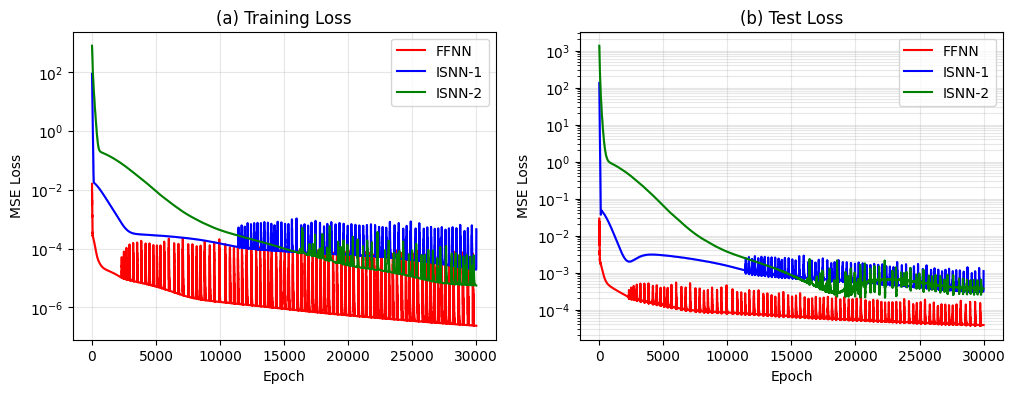

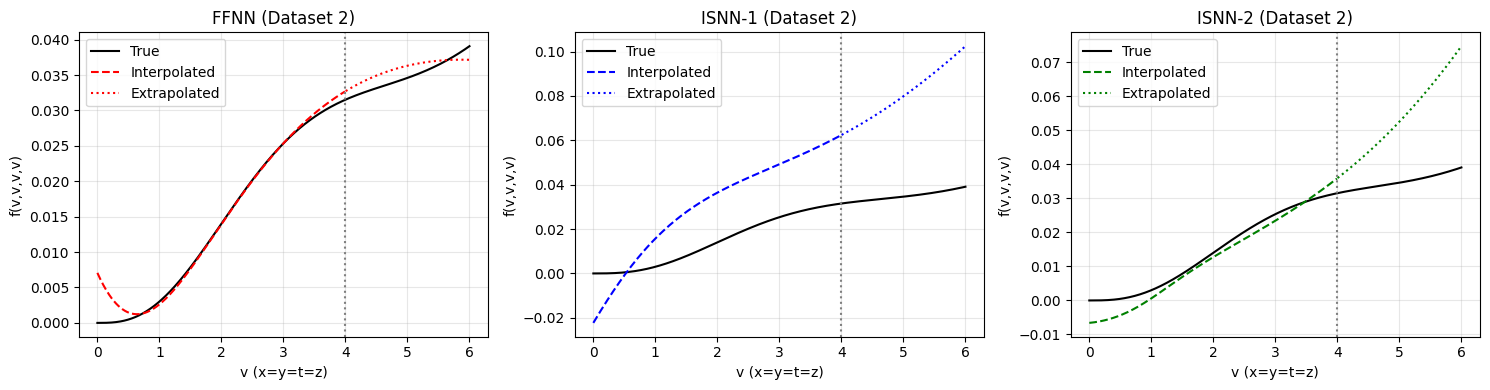


Done!


In [15]:

datasets = [
    ("Dataset 1", toy_function1),
    ("Dataset 2", toy_function2)
]

for name, func in datasets:

    print(f"\n--- {name} ---")

    x_tr, y_tr, t_tr, z_tr, f_tr = generate_dataset(500, 0, 4, func)
    x_te, y_te, t_te, z_te, f_te = generate_dataset(5000, 0, 6, func)


    models = {
        "FFNN": FFNN(),
        "ISNN-1": ISNN1(),
        "ISNN-2": ISNN2()
    }

    results = {}


    for model_name, model in models.items():

        print(f"\nTraining {model_name}...")

        train_loss, test_loss = train_model(
            model,
            x_tr, y_tr, z_tr, t_tr, f_tr,
            x_te, y_te, z_te, t_te, f_te,
            epochs=N_EPOCHS
        )

        results[model_name] = (train_loss, test_loss)


    plot_loss_curves(results)

    plot_behavior(
        models,
        lambda v1, v2, v3, v4: func(v1, v2, v3, v4),
        train_max=4, test_max=6, eq_name=name)

print("\nDone!")

3000 epochs(for better results because results become unstable almost after 1000-2000 epochs)

In [16]:
# tried with bboth 300000 and 3000
# N_EPOCHS = 30000
N_EPOCHS = 3000
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)


--- Dataset 1 ---

Training FFNN...
Epoch 1 | Train Loss: 5.423457 | Test Loss: 4.866127
Epoch 100 | Train Loss: 0.378769 | Test Loss: 1.011145
Epoch 200 | Train Loss: 0.241082 | Test Loss: 0.633415
Epoch 300 | Train Loss: 0.214196 | Test Loss: 0.487888
Epoch 400 | Train Loss: 0.205320 | Test Loss: 0.421689
Epoch 500 | Train Loss: 0.196986 | Test Loss: 0.380877
Epoch 600 | Train Loss: 0.186823 | Test Loss: 0.345685
Epoch 700 | Train Loss: 0.166630 | Test Loss: 0.308780
Epoch 800 | Train Loss: 0.120929 | Test Loss: 0.257629
Epoch 900 | Train Loss: 0.068580 | Test Loss: 0.251543
Epoch 1000 | Train Loss: 0.035545 | Test Loss: 0.313271
Epoch 1100 | Train Loss: 0.022997 | Test Loss: 0.388807
Epoch 1200 | Train Loss: 0.017915 | Test Loss: 0.434012
Epoch 1300 | Train Loss: 0.014397 | Test Loss: 0.464244
Epoch 1400 | Train Loss: 0.011417 | Test Loss: 0.490453
Epoch 1500 | Train Loss: 0.008944 | Test Loss: 0.514955
Epoch 1600 | Train Loss: 0.006993 | Test Loss: 0.538163
Epoch 1700 | Train Loss

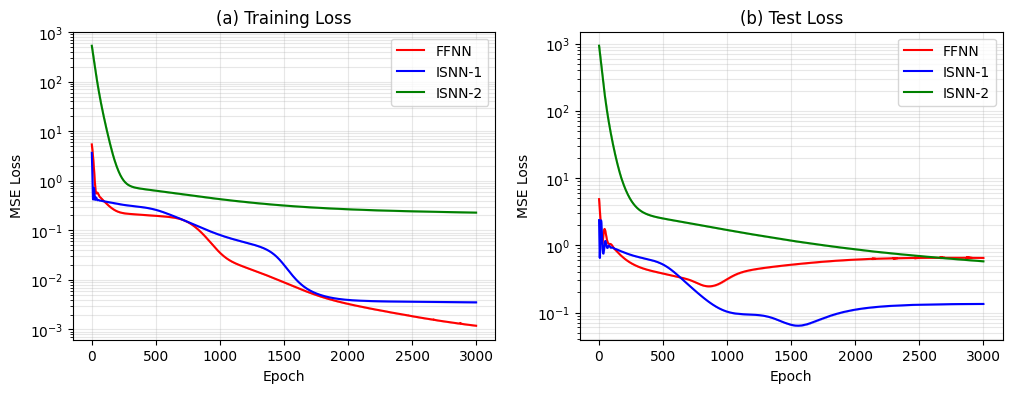

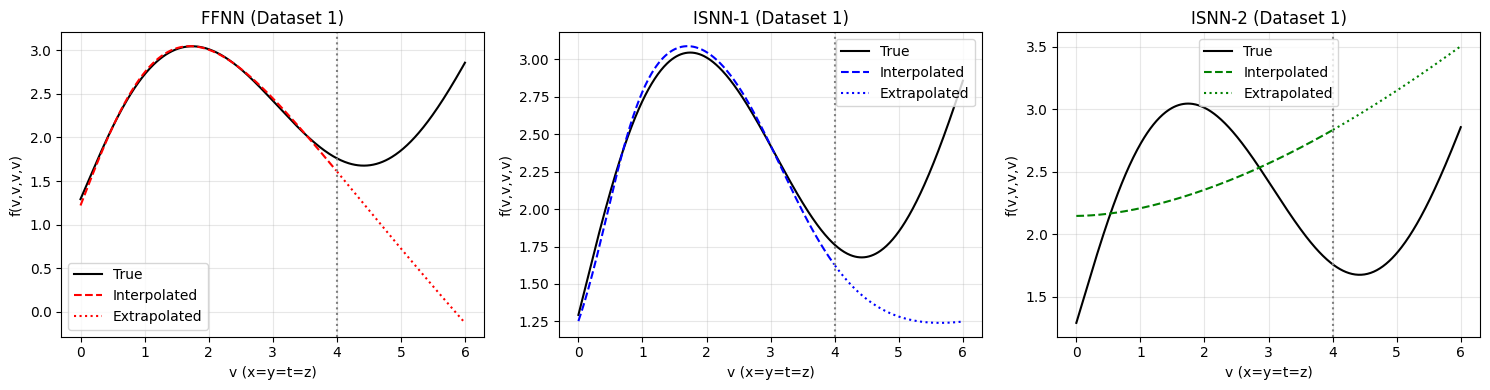


--- Dataset 2 ---

Training FFNN...
Epoch 1 | Train Loss: 0.016085 | Test Loss: 0.028581
Epoch 100 | Train Loss: 0.000231 | Test Loss: 0.001818
Epoch 200 | Train Loss: 0.000163 | Test Loss: 0.001365
Epoch 300 | Train Loss: 0.000109 | Test Loss: 0.000992
Epoch 400 | Train Loss: 0.000071 | Test Loss: 0.000722
Epoch 500 | Train Loss: 0.000050 | Test Loss: 0.000549
Epoch 600 | Train Loss: 0.000039 | Test Loss: 0.000443
Epoch 700 | Train Loss: 0.000032 | Test Loss: 0.000374
Epoch 800 | Train Loss: 0.000028 | Test Loss: 0.000329
Epoch 900 | Train Loss: 0.000025 | Test Loss: 0.000298
Epoch 1000 | Train Loss: 0.000023 | Test Loss: 0.000275
Epoch 1100 | Train Loss: 0.000022 | Test Loss: 0.000258
Epoch 1200 | Train Loss: 0.000021 | Test Loss: 0.000243
Epoch 1300 | Train Loss: 0.000020 | Test Loss: 0.000231
Epoch 1400 | Train Loss: 0.000019 | Test Loss: 0.000220
Epoch 1500 | Train Loss: 0.000018 | Test Loss: 0.000210
Epoch 1600 | Train Loss: 0.000017 | Test Loss: 0.000200
Epoch 1700 | Train Loss

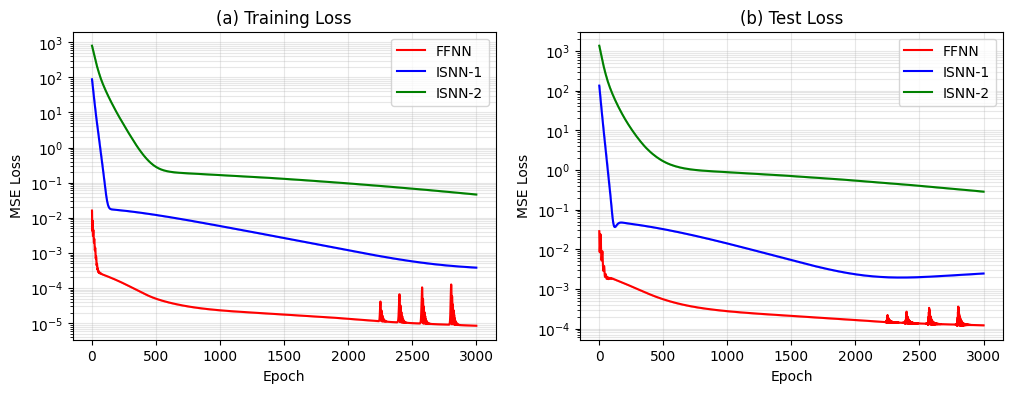

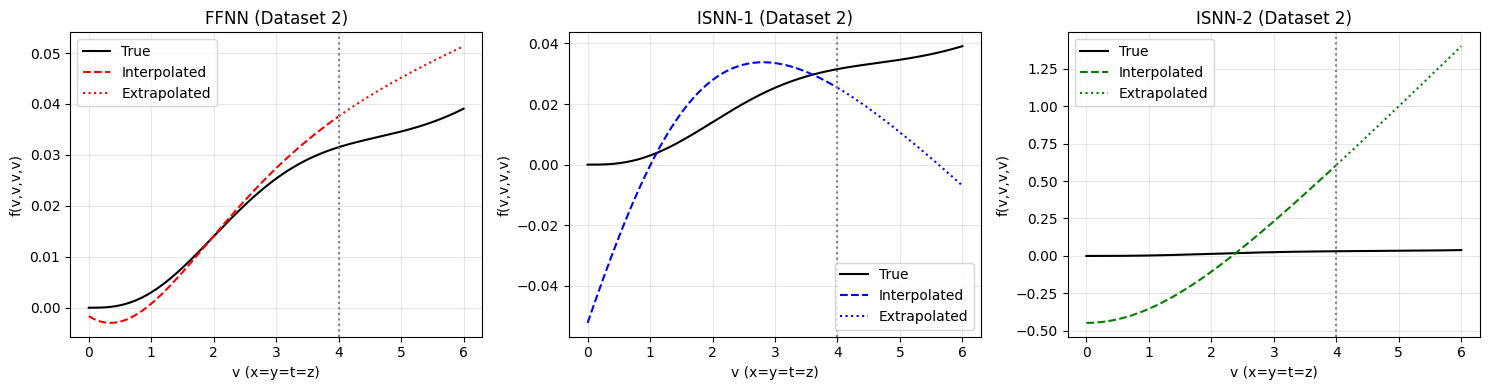


Done!


In [17]:
datasets = [
    ("Dataset 1", toy_function1),
    ("Dataset 2", toy_function2)
]

for name, func in datasets:

    print(f"\n--- {name} ---")

    x_tr, y_tr, t_tr, z_tr, f_tr = generate_dataset(500, 0, 4, func)
    x_te, y_te, t_te, z_te, f_te = generate_dataset(5000, 0, 6, func)


    models = {
        "FFNN": FFNN(),
        "ISNN-1": ISNN1(),
        "ISNN-2": ISNN2()
    }

    results = {}


    for model_name, model in models.items():

        print(f"\nTraining {model_name}...")

        train_loss, test_loss = train_model(
            model,
            x_tr, y_tr, z_tr, t_tr, f_tr,
            x_te, y_te, z_te, t_te, f_te,
            epochs=N_EPOCHS
        )

        results[model_name] = (train_loss, test_loss)


    plot_loss_curves(results)

    plot_behavior(
        models,
        lambda v1, v2, v3, v4: func(v1, v2, v3, v4),
        train_max=4, test_max=6, eq_name=name)

print("\nDone!")

Results would have been better if we had performed 10 different initializations, as instructed in the paper, but that would have taken several hours to train.